### Import Libraries

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from tensorflow.keras.models import load_model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


### Paths

In [3]:
TRAIN_DIR = Path("../processed/train")
VALID_DIR = Path("../processed/valid")
TEST_DIR = Path("../processed/test")

MODEL_DIR = Path("../models")

BASE_MODEL_PATH = "../models/best_model.keras"

### Configuration

In [4]:
IMAGE_SIZE = (224,224)

BATCH_SIZE = 32

FINE_TUNE_EPOCHS = 15

SEED = 42

### Load Datasets

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 3742 files belonging to 6 classes.


In [6]:
valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 801 files belonging to 6 classes.


In [7]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 805 files belonging to 6 classes.


### Prefetch

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

### Load Best Model

In [9]:
model = load_model(
    BASE_MODEL_PATH
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_1 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_1 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           7,686 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,281,044 (8.70 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 15,374 (60.06 KB)

### Find MobileNetV2 Layer

In [10]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 input_layer_4
1 sequential_1
2 mobilenetv2_1.00_224
3 global_average_pooling2d_1
4 dropout_1
5 dense_1


### Unfreeze MobileNetV2

In [11]:
base_model = model.layers[2]

base_model.trainable = True

### Freeze Most Layers

In [12]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [13]:
trainable_count = np.sum(
    [layer.trainable for layer in base_model.layers]
)

print("Trainable Layers:", trainable_count)

Trainable Layers: 30


### Recompile

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Callbacks

In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [16]:
checkpoint = ModelCheckpoint(
    "../models/fine_tuned_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [17]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2
)

### Fine Tune

In [18]:
history_fine = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.5684 - loss: 1.4897 - val_accuracy: 0.7203 - val_loss: 0.7908 - learning_rate: 1.0000e-05
Epoch 2/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.6518 - loss: 1.0049 - val_accuracy: 0.7179 - val_loss: 0.8167 - learning_rate: 1.0000e-05
Epoch 3/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6943 - loss: 0.8542 - val_accuracy: 0.7441 - val_loss: 0.7497 - learning_rate: 1.0000e-05
Epoch 4/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7084 - loss: 0.7971 - val_accuracy: 0.7466 - val_loss: 0.6999 - learning_rate: 1.0000e-05
Epoch 5/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.7421 - loss: 0.7223 - val_accuracy: 0.7553 - val_loss: 0.6583 - learning_rate: 1.0000e-05
Epoch 6/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7563 - loss: 0.6686 - val_accuracy: 0.7715 - val_loss: 0.6159 - learning_rate: 1.0000e-05
Epoch 7/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - acc

### Evaluate

In [19]:
test_loss, test_acc = model.evaluate(
    test_ds
)

print("Fine Tuned Test Accuracy:", test_acc)
print("Fine Tuned Test Loss:", test_loss)

26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 668ms/step - accuracy: 0.8745 - loss: 0.3920
Fine Tuned Test Accuracy: 0.8745341897010803
Fine Tuned Test Loss: 0.3919609785079956


### Compare Models

In [20]:
baseline_accuracy = 0.8161

fine_tuned_accuracy = test_acc

print("=" * 50)

print(
    f"Baseline Accuracy    : {baseline_accuracy:.4f}"
)

print(
    f"Fine Tuned Accuracy  : {fine_tuned_accuracy:.4f}"
)

print(
    f"Improvement          : {(fine_tuned_accuracy - baseline_accuracy)*100:.2f}%"
)

Baseline Accuracy    : 0.8161
Fine Tuned Accuracy  : 0.8745
Improvement          : 5.84%


### Imports for Evaluation

In [21]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Generate Predictions

In [22]:
y_true = np.concatenate(
    [y.numpy() for x, y in test_ds]
)

In [23]:
y_pred_probs = model.predict(test_ds)

26/26 ━━━━━━━━━━━━━━━━━━━━ 26s 815ms/step


In [24]:
y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

### Overall Metrics

In [25]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8745
Precision: 0.8739
Recall   : 0.8745
F1 Score : 0.8727


### Classification Report

In [30]:
test_ds_temp = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_ds_temp.class_names

print(class_names)

Found 805 files belonging to 6 classes.
['bacterial_leaf_blight', 'blast', 'brown_spot', 'healthy', 'leaf_scald', 'sheath_blight']


In [33]:


print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.83      0.82      0.83       130
                blast       0.89      0.78      0.83       149
           brown_spot       0.89      0.91      0.90       145
              healthy       0.89      1.00      0.94       122
           leaf_scald       0.85      0.79      0.82       123
        sheath_blight       0.90      0.96      0.93       136

             accuracy                           0.87       805
            macro avg       0.87      0.88      0.87       805
         weighted avg       0.87      0.87      0.87       805



### Classification Report DataFrame

In [34]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
bacterial_leaf_blight,0.829457,0.823077,0.826255,130.000000
blast,0.885496,0.778523,0.828571,149.000000
brown_spot,0.885906,0.910345,0.897959,145.000000
healthy,0.890511,1.000000,0.942085,122.000000
leaf_scald,0.850877,0.788618,0.818565,123.000000
sheath_blight,0.896552,0.955882,0.925267,136.000000
accuracy,0.874534,0.874534,0.874534,0.874534
macro avg,0.873133,0.876074,0.873117,805.000000
weighted avg,0.873858,0.874534,0.872706,805.000000


### Save Classification Report

In [35]:
report_df.to_csv(
    "../models/fine_tuned_classification_report.csv"
)

print("Classification report saved.")

Classification report saved.


### Confusion Matrix

In [36]:
cm = confusion_matrix(
    y_true,
    y_pred
)

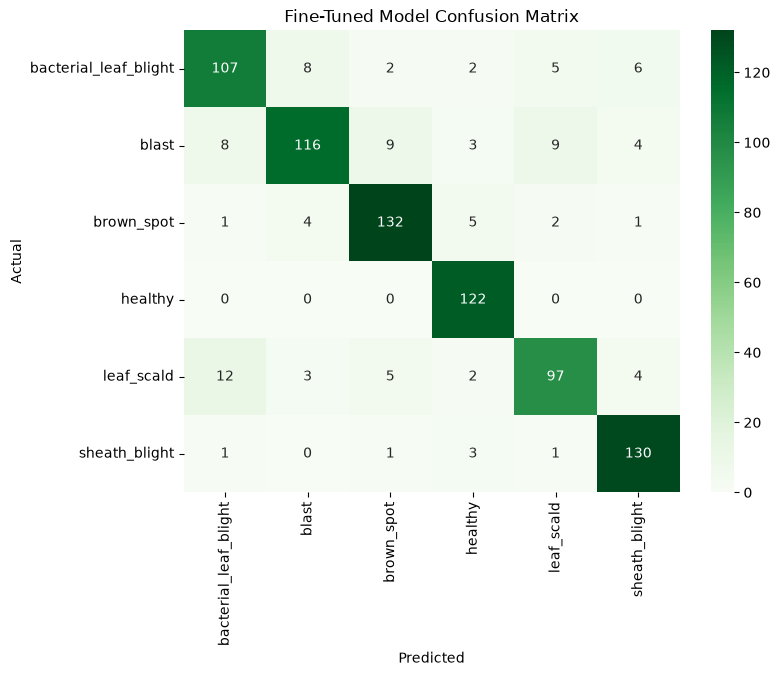

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Fine-Tuned Model Confusion Matrix"
)

plt.show()

### Per-Class Accuracy

In [38]:
class_accuracy = {}

for i, class_name in enumerate(class_names):

    indices = np.where(
        y_true == i
    )[0]

    correct = np.sum(
        y_pred[indices] == i
    )

    acc = correct / len(indices)

    class_accuracy[class_name] = acc

In [39]:
class_acc_df = pd.DataFrame(
    class_accuracy.items(),
    columns=[
        "Class",
        "Accuracy"
    ]
)

class_acc_df

,Class,Accuracy
0,bacterial_leaf_blight,0.823077
1,blast,0.778523
2,brown_spot,0.910345
3,healthy,1.000000
4,leaf_scald,0.788618
5,sheath_blight,0.955882


### Plot Class Accuracy

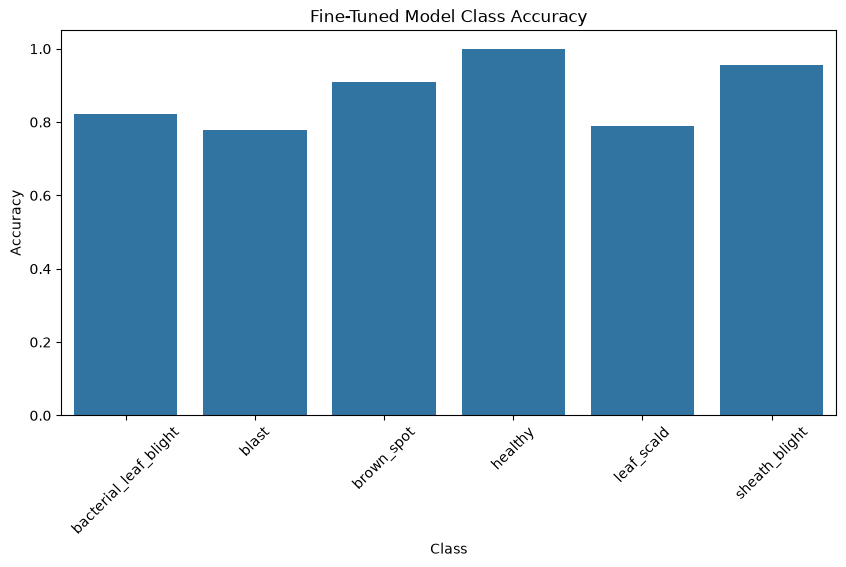

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=class_acc_df,
    x="Class",
    y="Accuracy"
)

plt.xticks(rotation=45)

plt.title(
    "Fine-Tuned Model Class Accuracy"
)

plt.show()

### Misclassified Images

In [41]:
images = np.concatenate(
    [x.numpy() for x, y in test_ds]
)

In [42]:
misclassified = np.where(
    y_true != y_pred
)[0]

print(
    f"Misclassified Images: {len(misclassified)}"
)

Misclassified Images: 101


### Show First 9 Errors

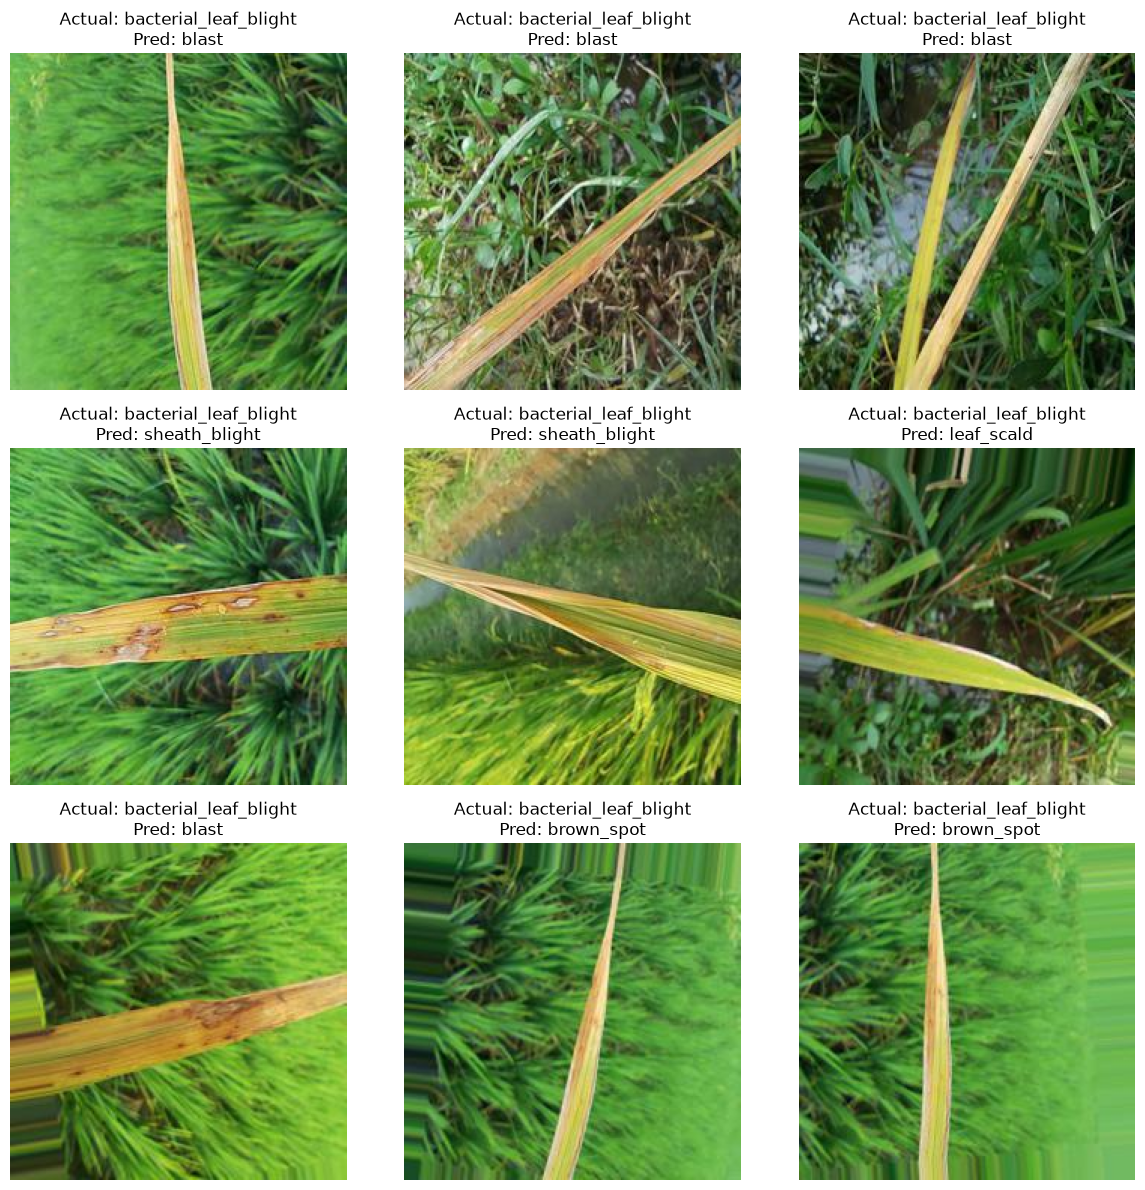

In [43]:
plt.figure(figsize=(12,12))

for i, idx in enumerate(
    misclassified[:9]
):

    plt.subplot(3,3,i+1)

    plt.imshow(
        images[idx].astype("uint8")
    )

    plt.title(
        f"Actual: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

### Final Comparison Table

In [44]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline MobileNetV2",
        "Fine-Tuned MobileNetV2"
    ],
    "Test Accuracy": [
        0.8161,
        accuracy
    ]
})

comparison_df

,Model,Test Accuracy
0,Baseline MobileNetV2,0.816100
1,Fine-Tuned MobileNetV2,0.874534


In [45]:
if accuracy > 0.8161:
    print("✅ Use Fine-Tuned Model")
else:
    print("✅ Keep Baseline Model")

✅ Use Fine-Tuned Model
